# Wind Portfolio Company Grids

This notebook creates two chart grids:
- Grid 1: one chart per company park (parks only)
- Grid 2: per-company comparison including **Total**

Both grids show yearly bars for:
- **Production (GWh)**
- **Income (€m)**
- **EBITDA (€m)**

In [54]:
import openpyxl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

In [55]:
# Path to your Excel file
excel_path = Path('Παραγωγή αιολικών.xlsx')

# Load workbook
wb = openpyxl.load_workbook(excel_path, data_only=False)
ws = wb[wb.sheetnames[0]]

print('Workbook loaded:', excel_path)
print('Sheet:', ws.title)

Workbook loaded: Παραγωγή αιολικών.xlsx
Sheet: Φύλλο1


## Data assumptions

The notebook uses these rows as company (park) rows:
- row 3 = Flamouria
- row 4 = Kali Chitsa
- row 6 = Litharoserma
- row 7 = Kefalaria

For each year block:
- Production is in the first column of the 3-column block
- Income is in the second column
- EBITDA is calculated as **75% of Income**

Grid 2 aggregates parks to legal entities using this mapping:
- **TAFF PRIME** = Flamouria + Kali Chitsa
- **PAP ENERGY** = Litharoserma + Kefalaria

Both grids include a computed **Total**.

In [56]:
years = [2021, 2022, 2023, 2024, 2025]

company_rows = {
    'Flamouria': 3,
    'Kali Chitsa': 4,
    'Litharoserma': 6,
    'Kefalaria': 7,
}

# Editable aggregation used in Grid 2
entity_to_parks = {
    'TAFF PRIME': ['Flamouria', 'Kali Chitsa'],
    'PAP ENERGY': ['Litharoserma', 'Kefalaria'],
}

production_gwh_by_entity = {name: [] for name in company_rows}
income_m_by_entity = {name: [] for name in company_rows}
ebitda_m_by_entity = {name: [] for name in company_rows}

total_production_gwh = []
total_income_m = []
total_ebitda_m = []

for i, year in enumerate(years):
    col_prod = 2 + i * 3      # B, E, H, K, N
    col_income = 3 + i * 3    # C, F, I, L, O

    year_total_prod_kwh = 0.0
    year_total_income_eur = 0.0

    for park, row in company_rows.items():
        prod_val = ws.cell(row, col_prod).value or 0
        income_val = ws.cell(row, col_income).value or 0

        year_total_prod_kwh += prod_val
        year_total_income_eur += income_val

        production_gwh_by_entity[park].append(prod_val / 1_000_000)
        income_m_by_entity[park].append(income_val / 1_000_000)
        ebitda_m_by_entity[park].append((income_val * 0.75) / 1_000_000)

    total_production_gwh.append(year_total_prod_kwh / 1_000_000)
    total_income_m.append(year_total_income_eur / 1_000_000)
    total_ebitda_m.append((year_total_income_eur * 0.75) / 1_000_000)

production_gwh_by_entity['Total'] = total_production_gwh
income_m_by_entity['Total'] = total_income_m
ebitda_m_by_entity['Total'] = total_ebitda_m

# Build legal-entity series for Grid 2
legal_entities = list(entity_to_parks.keys()) + ['Total']
production_gwh_by_legal = {name: [] for name in legal_entities}
income_m_by_legal = {name: [] for name in legal_entities}
ebitda_m_by_legal = {name: [] for name in legal_entities}

for y_idx in range(len(years)):
    for legal_entity, parks in entity_to_parks.items():
        production_gwh_by_legal[legal_entity].append(sum(production_gwh_by_entity[p][y_idx] for p in parks))
        income_m_by_legal[legal_entity].append(sum(income_m_by_entity[p][y_idx] for p in parks))
        ebitda_m_by_legal[legal_entity].append(sum(ebitda_m_by_entity[p][y_idx] for p in parks))

    production_gwh_by_legal['Total'].append(total_production_gwh[y_idx])
    income_m_by_legal['Total'].append(total_income_m[y_idx])
    ebitda_m_by_legal['Total'].append(total_ebitda_m[y_idx])

print('Parks:', list(company_rows.keys()))
print('Legal entities (Grid 2):', legal_entities)
print('Total Production (GWh):', total_production_gwh)

Parks: ['Flamouria', 'Kali Chitsa', 'Litharoserma', 'Kefalaria']
Legal entities (Grid 2): ['TAFF PRIME', 'PAP ENERGY', 'Total']
Total Production (GWh): [83.872568, 150.041893, 137.335515, 133.634567, 137.85440960000003]


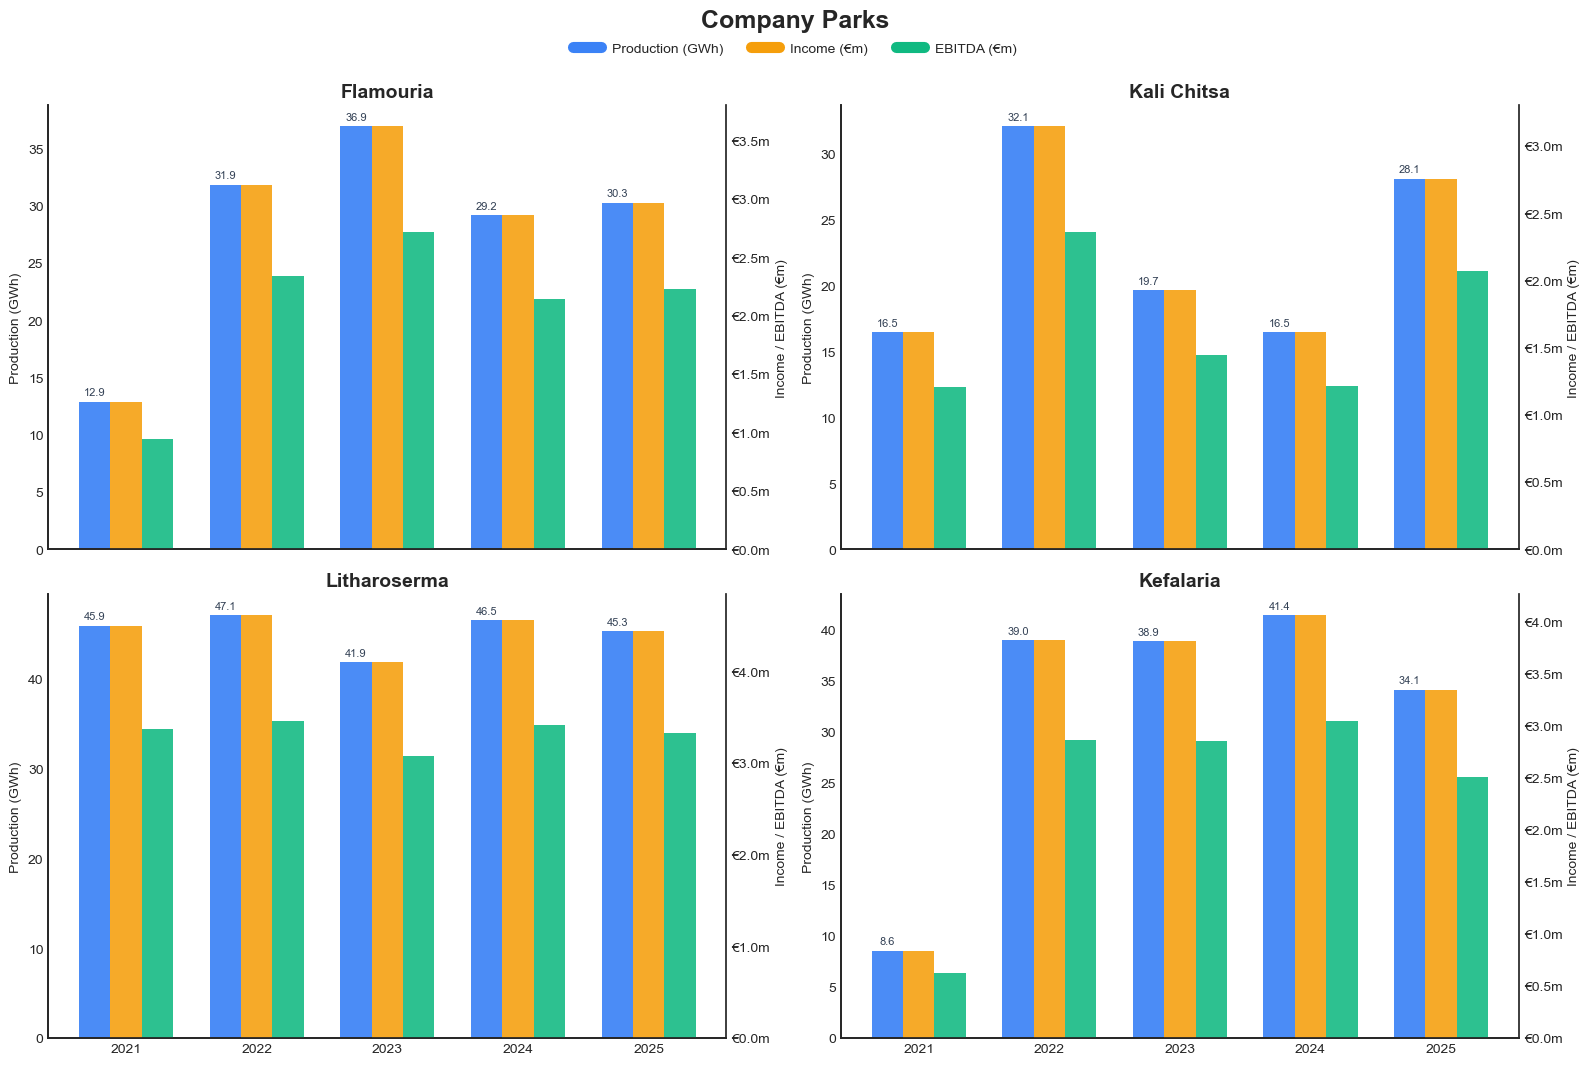

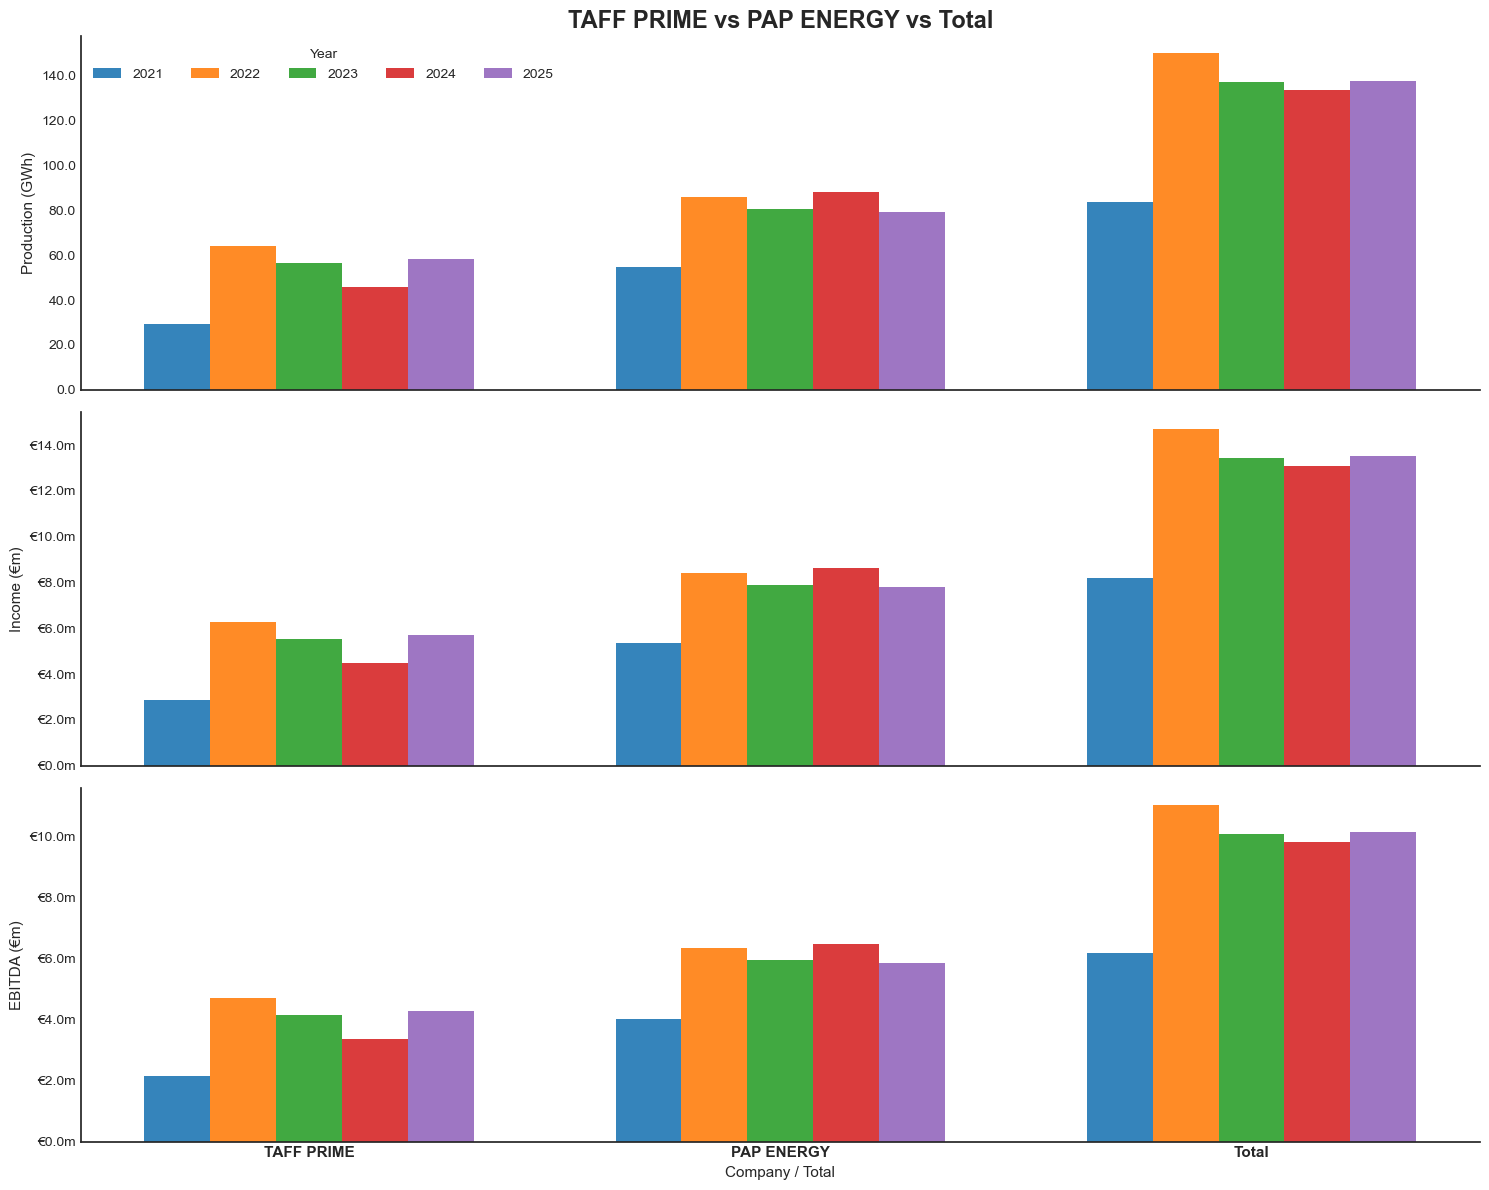

In [59]:
plt.style.use('seaborn-v0_8-white')

colors = {
    'production': '#3B82F6',
    'income': '#F59E0B',
    'ebitda': '#10B981',
}

# ---------- Grid 1: one subplot per park (parks only) ----------
park_entities = list(company_rows.keys())
n_parks = len(park_entities)
ncols = 2
nrows = (n_parks + ncols - 1) // ncols

fig_parks, axes = plt.subplots(nrows, ncols, figsize=(16, 5.2 * nrows), sharex=True)
axes = axes.flatten()

x = list(range(len(years)))
w = 0.24

for idx, entity in enumerate(park_entities):
    ax = axes[idx]
    prod_vals = production_gwh_by_entity[entity]
    income_vals = income_m_by_entity[entity]
    ebitda_vals = ebitda_m_by_entity[entity]

    x_prod = [v - w for v in x]
    x_income = x
    x_ebitda = [v + w for v in x]

    bars_prod = ax.bar(x_prod, prod_vals, width=w, color=colors['production'], alpha=0.92)
    ax.set_ylabel('Production (GWh)', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(years)
    ax.grid(False)

    ax_r = ax.twinx()
    ax_r.bar(x_income, income_vals, width=w, color=colors['income'], alpha=0.88)
    ax_r.bar(x_ebitda, ebitda_vals, width=w, color=colors['ebitda'], alpha=0.88)
    ax_r.set_ylabel('Income / EBITDA (€m)', fontsize=10)
    ax_r.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f'€{v:,.1f}m'))
    ax_r.grid(False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax_r.spines['top'].set_visible(False)
    ax.set_title(entity, fontsize=14, fontweight='semibold', pad=6)

    for bar in bars_prod:
        h = bar.get_height()
        ax.annotate(
            f'{h:,.1f}',
            xy=(bar.get_x() + bar.get_width() / 2, h),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=8,
            color='#334155',
        )

for idx in range(n_parks, len(axes)):
    axes[idx].axis('off')

fig_parks.suptitle('Company Parks', fontsize=18, fontweight='bold', y=1.02)
legend_handles = [
    plt.Line2D([0], [0], color=colors['production'], linewidth=8),
    plt.Line2D([0], [0], color=colors['income'], linewidth=8),
    plt.Line2D([0], [0], color=colors['ebitda'], linewidth=8),
]
legend_labels = ['Production (GWh)', 'Income (€m)', 'EBITDA (€m)']
fig_parks.legend(legend_handles, legend_labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.00), frameon=False)
fig_parks.tight_layout()
plt.show()

# ---------- Grid 2: legal entities + total ----------
entities_with_total = legal_entities
x2 = list(range(len(entities_with_total)))
w2 = 0.14

fig_company_total, axes2 = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
metric_rows = [
    ('Production (GWh)', production_gwh_by_legal, lambda v, pos: f'{v:,.1f}'),
    ('Income (€m)', income_m_by_legal, FuncFormatter(lambda v, pos: f'€{v:,.1f}m')),
    ('EBITDA (€m)', ebitda_m_by_legal, FuncFormatter(lambda v, pos: f'€{v:,.1f}m')),
]

for row_idx, (label, data_dict, formatter) in enumerate(metric_rows):
    ax = axes2[row_idx]

    for y_idx, year in enumerate(years):
        offset = (y_idx - (len(years) - 1) / 2) * w2
        xpos = [i + offset for i in x2]
        vals = [data_dict[e][y_idx] for e in entities_with_total]
        ax.bar(xpos, vals, width=w2, alpha=0.9, label=str(year) if row_idx == 0 else None)

    ax.set_ylabel(label, fontsize=11)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if hasattr(formatter, '__call__') and not isinstance(formatter, FuncFormatter):
        ax.yaxis.set_major_formatter(FuncFormatter(formatter))
    else:
        ax.yaxis.set_major_formatter(formatter)

axes2[0].set_title('TAFF PRIME vs PAP ENERGY vs Total', fontsize=17, fontweight='bold')
axes2[-1].set_xlabel('Company / Total', fontsize=11)
axes2[-1].set_xticks(x2)
axes2[-1].set_xticklabels(entities_with_total, fontsize=11, fontweight='semibold')
axes2[0].legend(title='Year', ncol=5, loc='upper left', frameon=False)

fig_company_total.tight_layout()
plt.show()

In [ ]:
# Optional: save both charts
output_png_1 = Path('wind_portfolio_parks_grid.png')
output_png_2 = Path('wind_portfolio_company_total_grid.png')

fig_parks.savefig(output_png_1, dpi=200, bbox_inches='tight')
fig_company_total.savefig(output_png_2, dpi=200, bbox_inches='tight')

print('Saved:', output_png_1.resolve())
print('Saved:', output_png_2.resolve())